<a href="https://colab.research.google.com/github/Adhira-Deogade/pytorch-learnings/blob/main/notebooks/plant_classfication_dataloader.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !rm -rf Plant_Classification

In [2]:
!git lfs install

Git LFS initialized.


In [3]:
!git clone https://huggingface.co/datasets/Mirkat/Plant_Classification

Cloning into 'Plant_Classification'...
remote: Enumerating objects: 2081, done.
remote: Total 2081 (delta 0), reused 0 (delta 0), pack-reused 2081 (from 1)
Receiving objects: 100% (2081/2081), 343.33 KiB | 5.82 MiB/s, done.
Resolving deltas: 100% (2/2), done.
Updating files: 100% (2119/2119), done.
Filtering content: 100% (2115/2115), 54.76 MiB | 1.69 MiB/s, done.


In [7]:
import os
# os.chdir('Plant_Classification')

In [12]:
os.chdir('/')

In [13]:
os.getcwd()

'/'

In [20]:
os.listdir('/content/Plant_Classification/Plant Detection2.v10i.folder/train/')

['basil',
 'poison ivy',
 'boxelder',
 'oregano',
 'mint',
 'parsely',
 'rose',
 'tulip',
 'blueash',
 'poison oak',
 'Unlabeled',
 'daisy',
 'oak leaves',
 'cilantro']

In [25]:
# I want to create a dataset of images, labels
# let's start with the train folder
# Let's get all classes
root_dir = '/content/Plant_Classification/Plant Detection2.v10i.folder/train/'
all_classes = os.listdir(root_dir)
print(all_classes)

['basil', 'poison ivy', 'boxelder', 'oregano', 'mint', 'parsely', 'rose', 'tulip', 'blueash', 'poison oak', 'Unlabeled', 'daisy', 'oak leaves', 'cilantro']


In [23]:
enumerated_classes = dict(enumerate(all_classes))
print(enumerated_classes)

{0: 'basil', 1: 'poison ivy', 2: 'boxelder', 3: 'oregano', 4: 'mint', 5: 'parsely', 6: 'rose', 7: 'tulip', 8: 'blueash', 9: 'poison oak', 10: 'Unlabeled', 11: 'daisy', 12: 'oak leaves', 13: 'cilantro'}


In [27]:
classes_dict = {
    all_classes[i]: i for i in range(len(all_classes))
}

In [28]:
print(classes_dict)

{'basil': 0, 'poison ivy': 1, 'boxelder': 2, 'oregano': 3, 'mint': 4, 'parsely': 5, 'rose': 6, 'tulip': 7, 'blueash': 8, 'poison oak': 9, 'Unlabeled': 10, 'daisy': 11, 'oak leaves': 12, 'cilantro': 13}


In [24]:
import polars as pl

In [26]:
for class_name in enumerated_classes.values():
  print(class_name)
  all_images = os.listdir(os.path.join(root_dir,class_name))
  print(all_images)
  break

basil
['basil43_jpeg.rf.36233aec04f45ee69a21e869d59c5f4c.jpg', 'basil_91_jpg.rf.59aca4fb7d3445b99956772598fa77cc.jpg', 'basil_74_jpg.rf.623f38963e43304c964f3ed66bb0a8c9.jpg', 'basil_66_jpg.rf.23f23d7ead0a4c6b7732efcda51550f5.jpg', 'basil_70_jpg.rf.b5cb11136ba6d70b1d8657bce9e07bba.jpg', 'basil_93_jpg.rf.98947ea4761dfabeabb738b5194b99ba.jpg', 'basil_42_jpg.rf.5d65fd508334369ac713b6f19a4207dd.jpg', 'basil_48_jpg.rf.7e5a05fdddf698fb756cb577c00c8ec5.jpg', 'basil_88_jpg.rf.1bd7391c8bf78e5f6eafad26440c10cd.jpg', 'basil_134_jpg.rf.8893b04567e31d89218ca7757d24c82d.jpg', 'basil_108_jpg.rf.31d0a09755640eb6f796c73270d18812.jpg', 'basil30_jpeg.rf.4a39ca8f25c041cc6436cbcd0521f456.jpg', 'basil_91_jpg.rf.9d336f5a360c94637e3200c0b819c3e1.jpg', 'basil_150_jpg.rf.67a52bff11ca5d0b7881fe1983635160.jpg', 'basil_72_jpg.rf.8cdc3bec19014bc2cda597aa527b3c17.jpg', 'basil24_jpeg.rf.6a192722eb1df7f13bdd704ddf51ddaf.jpg', 'basil_117_jpg.rf.b5e4e45e2ffa3961ed6c3b733e37056a.jpg', 'basil_42_jpg.rf.b7ae7fba76467a9b0f25

In [30]:
csv_filename = '/content/labelled_data.csv'
all_class_paths = []
all_categories = []
for class_dir in all_classes:
  numerical_category = classes_dict[class_dir]
  class_paths = os.listdir(os.path.join(root_dir, class_dir))
  numerical_cat_array = [numerical_category] * len(class_paths)
  all_class_paths.extend(class_paths)
  all_categories.extend(numerical_cat_array)
df = pl.DataFrame({"Image names": all_class_paths, "class names" :all_categories})
print(df)

df.write_csv(csv_filename, include_header=False)

shape: (1_308, 2)
┌─────────────────────────────────┬─────────────┐
│ Image names                     ┆ class names │
│ ---                             ┆ ---         │
│ str                             ┆ i64         │
╞═════════════════════════════════╪═════════════╡
│ basil43_jpeg.rf.36233aec04f45e… ┆ 0           │
│ basil_91_jpg.rf.59aca4fb7d3445… ┆ 0           │
│ basil_74_jpg.rf.623f38963e4330… ┆ 0           │
│ basil_66_jpg.rf.23f23d7ead0a4c… ┆ 0           │
│ basil_70_jpg.rf.b5cb11136ba6d7… ┆ 0           │
│ …                               ┆ …           │
│ coriander_58_jpg.rf.2c3cb60e3a… ┆ 13          │
│ cilantro_84_jpg.rf.24b08094a69… ┆ 13          │
│ cilantro_78_jpg.rf.76005bc9400… ┆ 13          │
│ cilantro_92_jpg.rf.169b2101bd3… ┆ 13          │
│ cilantro_51_jpg.rf.6796fbfbaf9… ┆ 13          │
└─────────────────────────────────┴─────────────┘


In [31]:

import torch
from torch.utils.data import random_split
generator1 = torch.Generator().manual_seed(42)
print(random_split(range(10), [3, 7], generator=generator1))


[<torch.utils.data.dataset.Subset object at 0x7d8e682ad350>, <torch.utils.data.dataset.Subset object at 0x7d8e682ad290>]


In [32]:
from torch.utils.data import Dataset
from torchvision.io import decode_image
class CustomPlantClassificationDatasetNumber(Dataset):
  def __init__(self, annotations_file, img_dir, classes_dict, transforms=None, target_transforms=None, train=True):
    self.img_labels = pl.read_csv(annotations_file)
    self.img_dir = img_dir
    self.classes_dict = classes_dict
    self.transforms = transforms
    self.target_transforms = target_transforms
  def __len__(self):
    return len(self.img_labels)
  def __getitem__(self, idx):
    label = self.img_labels[idx, 1]
    class_name = self.classes_dict[label]
    img_path = os.path.join(self.img_dir, class_name, self.img_labels[idx, 0])
    image = decode_image(img_path)
    if self.transforms:
      image = self.transforms(image)
    if self.target_transforms:
      label = self.target_transforms(label)
    return image, label

In [36]:
plant_dataset = CustomPlantClassificationDatasetNumber(csv_filename, root_dir, enumerated_classes)

In [39]:
print(plant_dataset)
print(plant_dataset[-1])
print(len(plant_dataset))

(tensor([[[255, 255, 255,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 255, 255],
         ...,
         [255, 255, 255,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 255, 255]],

        [[255, 255, 255,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 255, 255],
         ...,
         [255, 255, 255,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 255, 255]],

        [[255, 255, 255,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 255, 255],
         ...,
         [255, 255, 255,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 255, 255],
         [255, 255, 255,  ..., 255, 255, 255]]], dtype=torch.uint8), 13)
1307


In [40]:
# Split dataset into train test with torch
train_data, test_data = random_split(plant_dataset, [0.8, 0.2], generator=generator1)

In [41]:
print(len(train_data))
print(len(test_data))

1046
261


In [42]:
from torch.utils.data import DataLoader
train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=32, shuffle=True)

In [43]:
import numpy as np

# Helper function to show what's in the dataset
def imshow(imgs):
    # imgs = imgs / 2 + 0.5   # unnormalize
    npimgs = imgs.numpy()
    plt.imshow(np.transpose(npimgs, (1, 2, 0)))
    plt.show()

Feature batch shape: torch.Size([32, 3, 224, 224])
Labels batch shape: torch.Size([32])


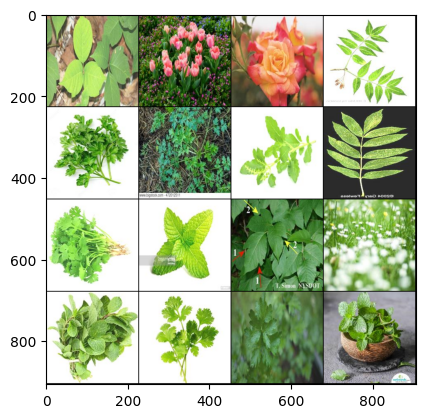

In [44]:

# Display image and label.
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img_grid = torchvision.utils.make_grid(train_features[0:16], nrow=4)
imshow(img_grid)
plt.show()